# 1. Entendimiento del Negocio

Una empresa de turismo quiere sugerir a sus asociados que restaurantes pueden visitar en la zona de playa de California. Contando con información de reseña de los restaurantes realizadas por otros usuarios.

# 2. Enfoque Analítico

Construir un modelo de recomendación que peuda ser valido por el usuario

# 3. Requerimiento de Datos

Se necesitan datos de las reseñas o calificaciones realizadas por los usuarios en los restaurantes

# 4. Recolección de Datos

In [2]:
import pandas as pd
import numpy as np

In [4]:
data = pd.read_csv('sb_restaurants_clean.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)
data

,user_id,business_id,stars,name
0,IlWLPCRQp8iqX0X-ExQccQ,bdfZdB2MTXlT6-RBjSIpQg,4.0,Pho Bistro
1,WSMIRegvrsEgFGEraf_LwQ,bdfZdB2MTXlT6-RBjSIpQg,5.0,Pho Bistro
2,2odfcvFhkb8SedI3vCLpmQ,bdfZdB2MTXlT6-RBjSIpQg,5.0,Pho Bistro
3,OEKu0Rts0spELpbnucDKmA,bdfZdB2MTXlT6-RBjSIpQg,5.0,Pho Bistro
4,4MSEWnnxKhNdh7GgNHM-YQ,bdfZdB2MTXlT6-RBjSIpQg,4.0,Pho Bistro
...,...,...,...,...
37825,pc3rsR3ji6na9OKucyXRuw,nhOMsw22-rz9kXSKwBZYAQ,2.0,Miracle At The Funk Zone
37826,LuPUwdJMWqahkSIb8SrI9w,nhOMsw22-rz9kXSKwBZYAQ,2.0,Miracle At The Funk Zone
37827,iubWB0-vNBWR3E_ZPeKPjA,nhOMsw22-rz9kXSKwBZYAQ,4.0,Miracle At The Funk Zone
37828,A4bsa7ykYRVCnb4h2vZALw,nhOMsw22-rz9kXSKwBZYAQ,5.0,Miracle At The Funk Zone


# 5. Exploración de los Datos

- Nulidad de los datos
- Cantidad de registros por elemento
- Exploración de las calificaciones

## Nulalidad de los datos

En caso de nulos, se elimina la fila, no se puede imputar

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37830 entries, 0 to 37829
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      37830 non-null  object 
 1   business_id  37830 non-null  object 
 2   stars        37830 non-null  float64
 3   name         37830 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


## Cantidad de registros por elemento

In [7]:
total_restaurant = data['name'].nunique()
total_users = data['user_id'].nunique()
total_reviews = data['stars'].count()

print(f'Número total de restaurantes: {total_restaurant}')
print(f'Número total de usuarios: {total_users}')
print(f'Número total de reseñas: {total_reviews}')

Número total de restaurantes: 659
Número total de usuarios: 23468
Número total de reseñas: 37830


In [10]:
idx = (data['user_id'] == '4MSEWnnxKhNdh7GgNHM-YQ')
print(f'El total de restaurantes calificados por el usuario es: {idx.sum()}')
data[idx]

El total de restaurantes calificados por el usuario es: 5


,user_id,business_id,stars,name
4,4MSEWnnxKhNdh7GgNHM-YQ,bdfZdB2MTXlT6-RBjSIpQg,4.0,Pho Bistro
1586,4MSEWnnxKhNdh7GgNHM-YQ,ju4YP8SLdR_BmWr_-Xh83Q,3.0,Phamous Cafe
10500,4MSEWnnxKhNdh7GgNHM-YQ,zJpZ-uQ_F0XVgK1u98uWSg,5.0,Gloria's Gourmet Kitchen
25128,4MSEWnnxKhNdh7GgNHM-YQ,IoAubn7CpU2rqcURxUo1MA,4.0,Barb's Pies
34522,4MSEWnnxKhNdh7GgNHM-YQ,yM7eA2uuH3Ch7OYVj3PKSw,5.0,Wabi Sabi


## Exploración de las calificaciones

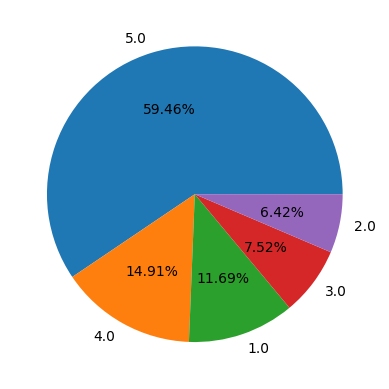

In [13]:
import matplotlib.pyplot as plt

plt.pie(
  x = data.stars.value_counts(),
  labels = data.stars.value_counts().index,
  autopct = '%0.2f%%',
)
plt.show()

# 6. Exploración del Modelo

- Crear la Matriz pivote
- Proceso de reducción de dimensionalidad
- Construir las matrices de similitud para la recomendación

## Matriz pivote

In [15]:
user_restaurant = data.pivot_table(
  values = 'stars',
  index = 'name',
  columns = 'user_id',
  fill_value = 0,
)
user_restaurant

user_id,---zemaUC8WeJeWKqS6p9Q,--2F5G5LKt3h2cAXJbZptg,--7XOV5T9yZR5w1DIy_Dog,--8YG4BoOWFGjdh9Fxop-w,--_QWYpJ2In2IgW_bouSuQ,--kinfHwmtdjz03g8B8z8Q,-0-Cbo-4YzKmoJXpnckwbg,-0-TtVhV4PIUoDpUCOC0uQ,-06H6BQ5cS5A5Jpd_iiwCA,-09MjuD1Q0KwSYwdYbAzMw,...,zyP0-AxYAb61wVroBgR0ng,zyQcIz_DR9CM-Tah3B7Tfw,zyWX5BNC9JhEsrrzaK-X9g,zyakHeX-9wVqU33jn6NMtA,zym3VpXHS4YWRMXUJ-MxsQ,zyvAj-SNHqHnrTN0X5_adA,zyzSePGcKiiA15e1takl4g,zzkJpm2B4PNPHnXg-CMyog,zzudZ50i88aStmQ6Ft1cVA,zzzGgfvrSJ4AQeKtcgocIw
name,,,,,,,,,,,,,,,,,,,,,
101 Deli,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1114 Sports Bar & Games,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Eggs & Pizza,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Slice of Woodstock's,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AH Juice Organics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zaytoon,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen Yai Thai Cuisine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zizzo's Coffeehouse,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Reducción dimensionalidad

In [17]:
from sklearn.decomposition import TruncatedSVD

SVD = TruncatedSVD(n_components = 659, random_state = 42)
SVD.fit(user_restaurant)

,n_components,659
,algorithm,'randomized'
,n_iter,5
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42
,tol,0.0


In [21]:
num_sv = 5
print(f"La cantidad de información explicada con los primeros {num_sv} vectores singulares es: ")
print('%0.2f%%' % (100 * (1 - (SVD.singular_values_[0:num_sv].sum() / (SVD.singular_values_).sum()))))

La cantidad de información explicada con los primeros 5 vectores singulares es: 
96.87%


In [24]:
SVD_5 = TruncatedSVD(n_components = 5, random_state = 42)
result_matriz = SVD_5.fit_transform(user_restaurant)
print(result_matriz.shape)
result_matriz

(659, 5)


array([[ 0.08325865,  0.0827159 ,  0.15625382,  0.03734063, -0.03711163],
       [ 2.22545948,  1.18559033,  0.81729322,  2.08507674, -0.9080326 ],
       [ 1.65760476,  0.62004894,  0.43417323,  1.29517647, -0.26026814],
       ...,
       [ 0.09117129,  0.02401858,  0.03505825,  0.06723986, -0.02856405],
       [ 1.88249287,  1.20883569,  1.13118453,  0.92939539, -0.46709159],
       [ 0.2850191 ,  0.08991918, -0.01642041,  0.06385593, -0.06107389]])

## Matrices recomendación para la similitud

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

corrMtx = np.corrcoef(result_matriz)
cossingMtx = cosine_similarity(result_matriz)

corrSpMtx = pd.DataFrame(result_matriz).corr(method = 'spearman')

### Correlacion de Pearson

In [26]:
corrMtx

array([[1.        , 0.48612014, 0.34456424, ..., 0.49746953, 0.74845422,
        0.26249176],
       [0.48612014, 1.        , 0.96755048, ..., 0.96533114, 0.88387554,
        0.78073389],
       [0.34456424, 0.96755048, 1.        , ..., 0.97918247, 0.83916384,
        0.86964616],
       ...,
       [0.49746953, 0.96533114, 0.97918247, ..., 1.        , 0.88425923,
        0.81955961],
       [0.74845422, 0.88387554, 0.83916384, ..., 0.88425923, 1.        ,
        0.81619977],
       [0.26249176, 0.78073389, 0.86964616, ..., 0.81955961, 0.81619977,
        1.        ]])

In [27]:
corrMtx[0:5,0:5]

array([[1.        , 0.48612014, 0.34456424, 0.86775303, 0.64899054],
       [0.48612014, 1.        , 0.96755048, 0.7913078 , 0.97006447],
       [0.34456424, 0.96755048, 1.        , 0.65070888, 0.89952492],
       [0.86775303, 0.7913078 , 0.65070888, 1.        , 0.86323812],
       [0.64899054, 0.97006447, 0.89952492, 0.86323812, 1.        ]])

#### Test

In [28]:
liked = 'Taco Bell'
names = user_restaurant.T.columns
names_list = list(names)
id_liked = names_list.index(liked)
corr_recom = corrMtx[id_liked]
corr_recom[0:10]

array([0.2174252 , 0.60299846, 0.73710169, 0.39440022, 0.48431101,
       0.48959878, 0.38728345, 0.32087249, 0.55873588, 0.67532528])

In [29]:
corr_recom[id_liked]

np.float64(0.9999999999999998)

In [31]:
print("Recomendaciones:")
list(names[(corr_recom > 0.95) & (corr_recom < 0.99)])

Recomendaciones:


['Bristol Farms - Santa Barbara',
 'Del Valle Grill',
 'El Rincon Bohemio',
 'Freebirds',
 'Fresco Cafe',
 'Gladden and Sons Produce',
 'Habit Burger Grill',
 "Jeannine's Bakery & Restaurant",
 "Norton's Pastrami & Deli",
 'Panaderia Veronica',
 'Pressed',
 'Revolver',
 'Starbucks',
 'Subway',
 'Taqueria El Bajio',
 'The Daily Grind',
 'The Spot',
 "Wendy's",
 'Zookers Cafe']

In [33]:
ids = (corr_recom > 0.95) & (corr_recom <= 1.0)
tmp = list()

for i in range(len(names[ids])):
  tmp.append((corr_recom[ids][i], names[ids][i]))

sorted(tmp, key=lambda x: x[0], reverse=True)

[(np.float64(0.9999999999999998), 'Taco Bell'),
 (np.float64(0.9810166772724538), 'The Spot'),
 (np.float64(0.9804296607202808), 'El Rincon Bohemio'),
 (np.float64(0.9803579700131995), 'Taqueria El Bajio'),
 (np.float64(0.9709444430453942), 'Gladden and Sons Produce'),
 (np.float64(0.9684308958870478), 'The Daily Grind'),
 (np.float64(0.965829238549177), 'Pressed'),
 (np.float64(0.9652135092893936), 'Fresco Cafe'),
 (np.float64(0.9638076056145918), 'Revolver'),
 (np.float64(0.9619481721566349), "Norton's Pastrami & Deli"),
 (np.float64(0.9590613859996123), 'Freebirds'),
 (np.float64(0.9588960452271419), 'Subway'),
 (np.float64(0.958300434495651), 'Zookers Cafe'),
 (np.float64(0.9576559742148788), "Jeannine's Bakery & Restaurant"),
 (np.float64(0.957365210628826), 'Del Valle Grill'),
 (np.float64(0.956653700681346), 'Panaderia Veronica'),
 (np.float64(0.9562925605387255), 'Bristol Farms - Santa Barbara'),
 (np.float64(0.9560523694457617), 'Habit Burger Grill'),
 (np.float64(0.9528886415